#  Использование предобученных моделей для классификации изображений

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

__Выполнила Ларькова Дарья__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/vision/0.16/transforms.html#v2-api-reference-recommended
* https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html
* https://pytorch.org/vision/stable/models.html
* https://albumentations.ai/docs/getting_started/image_augmentation/

## Задачи для совместного разбора

In [1]:
# Используемые библиотеки
import torch
import torch.nn as nn
import torchvision.models as models
try:
    from torchsummary import summary
except ImportError:
    summary = None
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from PIL import Image
import os
import zipfile
from collections import Counter
from tqdm import tqdm
import torch.optim as optim
import time
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
import glob
import io
from pathlib import Path


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство:', device)


Устройство: cuda


In [3]:
# 🟩 - всё в порядке
# 🟧 - всё плохо

# Основные семейства предобученных моделей:

- ResNet (18, 34, 50, 101, 152)

- VGG (11, 13, 16, 19)

- DenseNet (121, 169, 201, 161)

- MobileNet (v2, v3)

- EfficientNet (b0-b3)

1\. Загрузите предобученную модель из `torchvision`. Познакомьтесь с ее архитектурой. Заморозьте веса нескольких слоев.

In [4]:
def load_and_analyze_model(model_name='resnet18', num_classes=1000):
    print(f"\n=== ЗАГРУЗКА МОДЕЛИ {model_name.upper()} ===")
    if model_name == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    elif model_name == 'vgg16':
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    else:
        raise ValueError(f'Неподдерживаемая модель: {model_name}')

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Тип модели: {type(model).__name__}')
    print(f'Всего параметров: {total_params:,}')
    print(f'Обучаемых параметров: {trainable_params:,}')
    analyze_model_layers(model, model_name)
    return model


In [5]:
def analyze_model_layers(model, model_name):
    print(f"\n--- ДЕТАЛЬНЫЙ АНАЛИЗ СЛОЕВ {model_name.upper()} ---")

    conv_layers = []
    linear_layers = []
    batch_norm_layers = []
    other_layers = []

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            conv_layers.append((name, module))
        elif isinstance(module, nn.Linear):
            linear_layers.append((name, module))
        elif isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
            batch_norm_layers.append((name, module))
        elif len(list(module.children())) == 0:
            other_layers.append((name, type(module).__name__))

    print(f"Сверточных слоев: {len(conv_layers)}")
    print(f"Линейных слоев: {len(linear_layers)}")
    print(f"BatchNorm слоев: {len(batch_norm_layers)}")
    print(f"Других слоев: {len(other_layers)}")

    print(f"\nПервые 3 сверточных слоя:")
    for name, layer in conv_layers[:3]:
        print(f"  {name}: {layer.in_channels} -> {layer.out_channels}, "
              f"kernel={layer.kernel_size}, stride={layer.stride}")

    print(f"\nЛинейные слои:")
    for name, layer in linear_layers:
        print(f"  {name}: {layer.in_features} -> {layer.out_features}")

    return conv_layers, linear_layers, batch_norm_layers

In [6]:
def visualize_model_structure(model, model_name):
    try:
        print(f"\n--- СВОДКА МОДЕЛИ {model_name.upper()} ---")
        if 'resnet' in model_name or 'vgg' in model_name:
            input_size = (3, 224, 224)
        elif 'inception' in model_name:
            input_size = (3, 299, 299)
        else:
            input_size = (3, 224, 224)

        summary(model, input_size, device='cpu')
    except:
        print(model)

In [7]:
model_name = 'resnet18'
model = load_and_analyze_model(model_name)


=== ЗАГРУЗКА МОДЕЛИ RESNET18 ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/crazy/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:04<00:00, 11.4MB/s]

Тип модели: ResNet
Всего параметров: 11,689,512
Обучаемых параметров: 11,689,512

--- ДЕТАЛЬНЫЙ АНАЛИЗ СЛОЕВ RESNET18 ---
Сверточных слоев: 20
Линейных слоев: 1
BatchNorm слоев: 20
Других слоев: 11

Первые 3 сверточных слоя:
  conv1: 3 -> 64, kernel=(7, 7), stride=(2, 2)
  layer1.0.conv1: 64 -> 64, kernel=(3, 3), stride=(1, 1)
  layer1.0.conv2: 64 -> 64, kernel=(3, 3), stride=(1, 1)

Линейные слои:
  fc: 512 -> 1000


In [8]:
def freeze_model_layers(model, model_name, strategy='freeze_first_n', num_layers=None, pattern=None):
    print(f"\n=== ЗАМОРОЗКА СЛОЕВ ({strategy.upper()}) ===")

    initial_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    if strategy == 'freeze_first_n' and num_layers is not None:
        layers_frozen = 0
        for name, param in model.named_parameters():
            if layers_frozen < num_layers:
                param.requires_grad = False
                layers_frozen += 1
            else:
                param.requires_grad = True

    final_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = initial_trainable - final_trainable
    print(f"Изначально обучаемых параметров: {initial_trainable:,}")
    print(f"После заморозки обучаемых параметров: {final_trainable:,}")
    print(f"Заморожено параметров: {frozen_params:,}")
    print(f"Процент замороженных параметров: {frozen_params/initial_trainable*100:.1f}%")

    print(f"\nОбучаемые слои:")
    trainable_count = 0
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(f"  ✓ {name}")
            trainable_count += 1
            if trainable_count >= 10: 
                print(f"  ... и еще {sum(1 for n, p in model.named_parameters() if p.requires_grad) - trainable_count} слоев")
                break

    return model

In [9]:
def count_parameters_detailed(model): 
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = total_params - trainable_params
    return total_params, trainable_params, non_trainable_params

In [10]:
def visualize_strategy_comparison(models, strategy_names):
    trainable_params = []
    total_params = []
    for model in models:
        total, trainable, non_trainable = count_parameters_detailed(model)
        trainable_params.append(trainable)
        total_params.append(total)

    print(f"\n=== ТАБЛИЦА СРАВНЕНИЯ СТРАТЕГИЙ ===")
    print(f"{'Стратегия':<20} {'Всего параметров':<18} {'Обучаемых':<12} {'% обучаемых':<12}")
    print("-" * 65)
    for name, total, trainable in zip(strategy_names, total_params, trainable_params):
        percentage = trainable/total*100
        print(f"{name:<20} {total:<18,} {trainable:<12,} {percentage:<12.1f}")

In [11]:
def setup_model_for_transfer_learning(model_name='resnet18', num_classes=10, freeze_strategy='freeze_backbone'):
    """Корректная настройка классификатора для transfer learning."""
    model = load_and_analyze_model(model_name)

    if freeze_strategy == 'freeze_backbone':
        for p in model.parameters():
            p.requires_grad = False

    if model_name.lower().startswith('resnet'):
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        print(f'Заменен fc: {in_features} -> {num_classes}')
    elif model_name.lower().startswith('vgg'):
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)
        print(f'Заменен classifier[-1]: {in_features} -> {num_classes}')
    else:
        raise ValueError('Для этой модели замена классификатора не реализована')

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Обучаемых параметров после настройки: {trainable:,}')
    return model


In [12]:
def modify_classifier(model, model_name, num_classes):
    """
    Модификация классификатора для нового числа классов
    """
    print(f"\n=== МОДИФИКАЦИЯ КЛАССИФИКАТОРА ДЛЯ {num_classes} КЛАССОВ ===")

    model_name_lower = model_name.lower()

    if 'resnet' in model_name_lower:
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        print(f"🟩 Заменен fc слой: {in_features} -> {num_classes}")
    return model

In [13]:
num_classes = 10
# model = modify_classifier(model, model_name, num_classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Заморозить первые 50 слоев
model_ = load_and_analyze_model(model_name)
model_ = modify_classifier(model_, model_name, num_classes)
model_ = freeze_model_layers(model_, model_name, strategy='freeze_first_n', num_layers=50)


# Для частично замороженной модели
optimizer_ = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_.parameters()),
    lr=0.001
)
print(f"Optimizer 2 (freeze first N): {len(list(optimizer_.param_groups[0]['params']))} параметров")


=== ЗАГРУЗКА МОДЕЛИ RESNET18 ===
Тип модели: ResNet
Всего параметров: 11,689,512
Обучаемых параметров: 11,689,512

--- ДЕТАЛЬНЫЙ АНАЛИЗ СЛОЕВ RESNET18 ---
Сверточных слоев: 20
Линейных слоев: 1
BatchNorm слоев: 20
Других слоев: 11

Первые 3 сверточных слоя:
  conv1: 3 -> 64, kernel=(7, 7), stride=(2, 2)
  layer1.0.conv1: 64 -> 64, kernel=(3, 3), stride=(1, 1)
  layer1.0.conv2: 64 -> 64, kernel=(3, 3), stride=(1, 1)

Линейные слои:
  fc: 512 -> 1000

=== МОДИФИКАЦИЯ КЛАССИФИКАТОРА ДЛЯ 10 КЛАССОВ ===
🟩 Заменен fc слой: 512 -> 10

=== ЗАМОРОЗКА СЛОЕВ (FREEZE_FIRST_N) ===
Изначально обучаемых параметров: 11,181,642
После заморозки обучаемых параметров: 4,858,378
Заморожено параметров: 6,323,264
Процент замороженных параметров: 56.6%

Обучаемые слои:
  ✓ layer4.0.bn2.bias
  ✓ layer4.0.downsample.0.weight
  ✓ layer4.0.downsample.1.weight
  ✓ layer4.0.downsample.1.bias
  ✓ layer4.1.conv1.weight
  ✓ layer4.1.bn1.weight
  ✓ layer4.1.bn1.bias
  ✓ layer4.1.conv2.weight
  ✓ layer4.1.bn2.weight
  

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Используя реализацию из `torchvision`, cоздайте модель `vgg16` и загрузите предобученные веса `IMAGENET1K_V1`. Выведите на экран структуру модели, количество слоев и количество настраиваемых (`requires_grad==True`) параметров модели.

- [ ] Проверено на семинаре

In [14]:
# VGG16 с предобученными весами ImageNet
VGG_WEIGHTS = models.VGG16_Weights.IMAGENET1K_V1


In [15]:
def load_vgg16_with_pretrained_weights():
    model = models.vgg16(weights=VGG_WEIGHTS)
    print('VGG16 с весами IMAGENET1K_V1 загружена')
    return model


In [16]:
def analyze_vgg16_structure(model):
    conv_layers = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
    linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]
    leaf_modules = [m for m in model.modules() if len(list(m.children())) == 0]
    print('Conv2d:', len(conv_layers))
    print('Linear:', len(linear_layers))
    print('Слоёв с обучаемыми весами (Conv2d + Linear):', len(conv_layers) + len(linear_layers))
    print('Всего leaf-модулей (включая ReLU/Pool/Dropout):', len(leaf_modules))
    return conv_layers, linear_layers


In [17]:
def print_detailed_architecture(model):
    print(model)


In [18]:
def count_parameters_detailed(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    print(f'Всего параметров: {total:,}')
    print(f'Настраиваемых (requires_grad=True): {trainable:,}')
    print(f'Замороженных: {frozen:,}')
    return total, trainable, frozen


In [19]:
def analyze_features_structure(model):
    print('Количество модулей в features:', len(model.features))
    for i, layer in enumerate(model.features):
        print(f'{i:2d}: {layer}')


In [20]:
def analyze_classifier_structure(model):
    print('Количество модулей в classifier:', len(model.classifier))
    for i, layer in enumerate(model.classifier):
        print(f'{i}: {layer}')


In [21]:
def print_model_summary(model):
    print('VGG16: 13 Conv2d + 3 Linear = 16 слоёв с обучаемыми весами.')
    print('Название VGG16 относится именно к этим 16 слоям; ReLU/Pooling/Dropout в число 16 не входят.')


In [22]:
# Дополнительная проверка распределения параметров по двум крупным частям модели
def parameter_distribution(model):
    features = sum(p.numel() for p in model.features.parameters())
    classifier = sum(p.numel() for p in model.classifier.parameters())
    print(f'features: {features:,}')
    print(f'classifier: {classifier:,}')
    return features, classifier


In [23]:
def check_pretrained_status(model):
    assert isinstance(model, models.VGG)
    print('Использованы веса:', VGG_WEIGHTS)


In [24]:
print('=' * 70)
print('ЗАДАНИЕ 1 — VGG16 + IMAGENET1K_V1')
print('=' * 70)
vgg16_model = load_vgg16_with_pretrained_weights().to(device)
print_detailed_architecture(vgg16_model)
analyze_vgg16_structure(vgg16_model)
count_parameters_detailed(vgg16_model)
parameter_distribution(vgg16_model)
check_pretrained_status(vgg16_model)
print_model_summary(vgg16_model)


ЗАДАНИЕ 1 — VGG16 + IMAGENET1K_V1
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/crazy/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|████████████████████████████████████████████████████████████████████████████████| 528M/528M [00:51<00:00, 10.8MB/s]


VGG16 с весами IMAGENET1K_V1 загружена
VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_

# Особенности VGG16:

• Глубина: 16 слоев (13 сверточных + 3 полносвязных)

• Размер входа: 224x224x3

• Размер выхода: 1000 классов (ImageNet)

• Активации: ReLU

• Pooling: MaxPooling 2x2

• Dropout: в classifier (p=0.5)


<p class="task" id="2"></p>

2\. Создайте датасет `CatBreeds` на основе данных из архива `cat_breeds_4.zip`. Разбейте датасет на обучающее и тестовое множество в соотношении 80 на 20%.

К обучающему датасету примените следующее преобразование: приведите картинки к размеру 256x256, затем обрежьте по центру с размером 224х224, затем переведите изображения в тензор и нормализуйте значения интенсивности пикселей (`mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)`).

К тестовому датасету примените преобразование `VGG16_Weights.IMAGENET1K_V1.transforms`.

- [ ] Проверено на семинаре

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
class CatBreedsDataset(Dataset):
    def __init__(self, image_paths, labels, class_to_idx, transform=None):
        self.image_paths = list(image_paths)
        self.labels = list(labels)
        self.class_to_idx = dict(class_to_idx)
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        label = self.class_to_idx[self.labels[idx]]
        return image, label

    def get_class_mapping(self):
        return self.class_to_idx, self.idx_to_class


In [27]:
def extract_zip(zip_path, extract_to):
    if not os.path.isfile(zip_path):
        raise FileNotFoundError(f'Архив не найден: {zip_path}')
    os.makedirs(extract_to, exist_ok=True)
    # Повторный Run All не требует повторной распаковки, если изображения уже есть.
    existing = glob.glob(os.path.join(extract_to, '**', '*.jpg'), recursive=True)
    if not existing:
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(extract_to)
        print('Архив распакован:', extract_to)
    else:
        print('Используем уже распакованные данные:', extract_to)
    return extract_to


In [28]:
def find_images_and_labels(data_dir):
    extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    image_paths, labels = [], []
    for root, _, files in os.walk(data_dir):
        for name in files:
            if Path(name).suffix.lower() in extensions:
                path = os.path.join(root, name)
                label = os.path.basename(root)
                if label and not label.startswith('.'):
                    image_paths.append(path)
                    labels.append(label)
    if not image_paths:
        raise RuntimeError(f'В {data_dir} не найдено изображений')
    return image_paths, labels


In [29]:
def create_catbreeds_datasets(zip_path='cat_breeds_4.zip', data_dir='./cat_breeds_data'):
    extract_zip(zip_path, data_dir)
    image_paths, labels = find_images_and_labels(data_dir)

    classes = sorted(set(labels))
    class_to_idx = {name: i for i, name in enumerate(classes)}
    idx_to_class = {i: name for name, i in class_to_idx.items()}

    train_paths, test_paths, train_labels, test_labels = train_test_split(
        image_paths, labels, test_size=0.20, random_state=42, stratify=labels
    )

    train_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
    ])
    test_transform = VGG_WEIGHTS.transforms()

    train_dataset = CatBreedsDataset(train_paths, train_labels, class_to_idx, train_transform)
    test_dataset = CatBreedsDataset(test_paths, test_labels, class_to_idx, test_transform)

    print('Классы:', classes)
    print(f'Train: {len(train_dataset)} ({100*len(train_dataset)/(len(train_dataset)+len(test_dataset)):.1f}%)')
    print(f'Test:  {len(test_dataset)} ({100*len(test_dataset)/(len(train_dataset)+len(test_dataset)):.1f}%)')

    return {
        'train_dataset': train_dataset,
        'test_dataset': test_dataset,
        'train_paths': train_paths,
        'test_paths': test_paths,
        'train_labels': train_labels,
        'test_labels': test_labels,
        'class_to_idx': class_to_idx,
        'idx_to_class': idx_to_class,
        'train_transform': train_transform,
        'test_transform': test_transform,
    }


In [30]:
def verify_transforms(train_dataset, test_dataset):
    x_train, y_train = train_dataset[0]
    x_test, y_test = test_dataset[0]
    print('Train tensor:', tuple(x_train.shape), x_train.dtype)
    print('Test tensor: ', tuple(x_test.shape), x_test.dtype)
    assert tuple(x_train.shape) == (3, 224, 224)
    assert tuple(x_test.shape) == (3, 224, 224)


In [31]:
def denormalize_imagenet(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device)[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device)[:, None, None]
    return (x * std + mean).clamp(0, 1)

def visualize_samples(dataset, idx_to_class, num_samples=6, title='Примеры'):
    n = min(num_samples, len(dataset))
    fig, axes = plt.subplots(2, int(np.ceil(n/2)), figsize=(12, 6))
    axes = np.array(axes).reshape(-1)
    for ax, idx in zip(axes, np.linspace(0, len(dataset)-1, n, dtype=int)):
        image, label = dataset[idx]
        ax.imshow(denormalize_imagenet(image).permute(1,2,0).cpu())
        ax.set_title(idx_to_class[int(label)])
        ax.axis('off')
    for ax in axes[n:]: ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


In [32]:
def create_dataloaders(train_dataset, test_dataset, batch_size=32):
    workers = 0 if os.name == 'nt' else 2
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=workers,
                              pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=workers,
                             pin_memory=torch.cuda.is_available())
    return train_loader, test_loader


Используем уже распакованные данные: ./cat_breeds_data
Классы: ['American Shorthair', 'Persian', 'Russian Blue', 'Tiger']
Train: 3200 (80.0%)
Test:  800 (20.0%)
Train tensor: (3, 224, 224) torch.float32
Test tensor:  (3, 224, 224) torch.float32


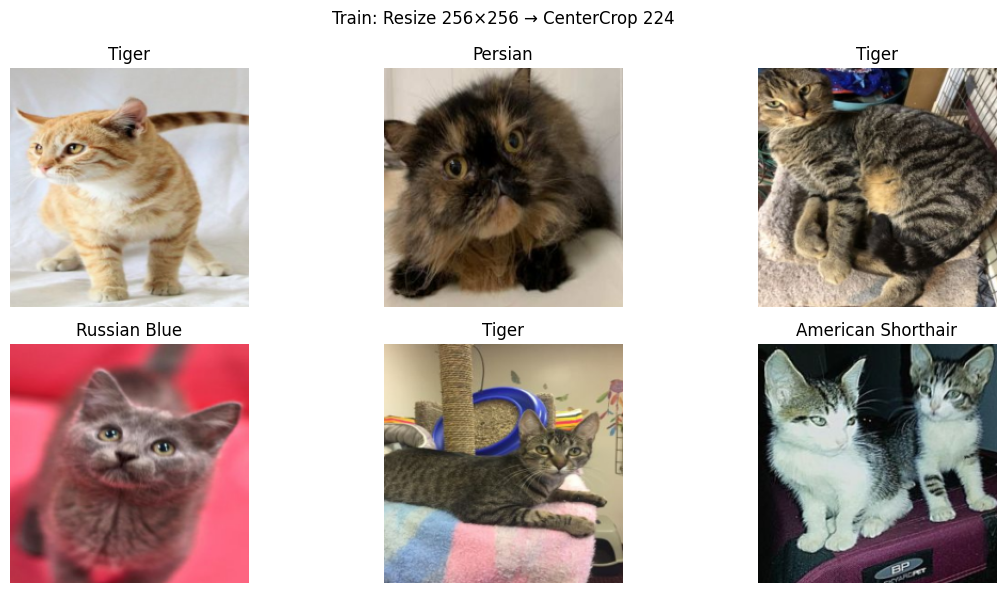

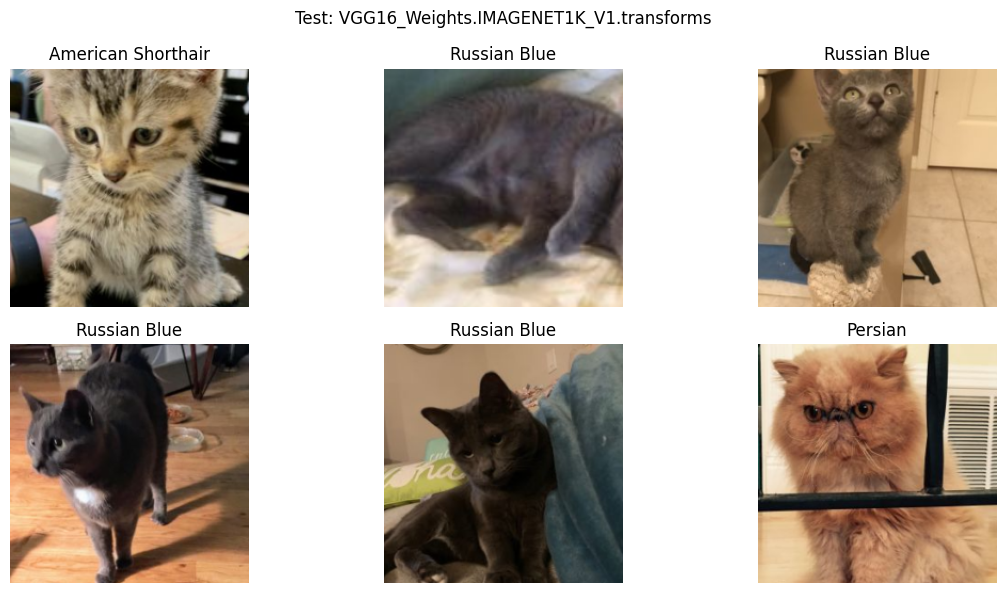

In [33]:
zip_path = 'cat_breeds_4.zip'
data_dir = './cat_breeds_data'
cat_data = create_catbreeds_datasets(zip_path, data_dir)

train_dataset = cat_data['train_dataset']
test_dataset = cat_data['test_dataset']
class_to_idx = cat_data['class_to_idx']
idx_to_class = cat_data['idx_to_class']
num_classes = len(class_to_idx)

verify_transforms(train_dataset, test_dataset)
visualize_samples(train_dataset, idx_to_class, title='Train: Resize 256×256 → CenterCrop 224')
visualize_samples(test_dataset, idx_to_class, title='Test: VGG16_Weights.IMAGENET1K_V1.transforms')
train_loader, test_loader = create_dataloaders(train_dataset, test_dataset, batch_size=32)


<p class="task" id="3"></p>

3\. Заморозьте все веса модели из предыдущего задания. Замените последний слой `Linear` классификатора на новый слой, соответствующий задаче. После изменения последнего слоя выведите на экран количество настраиваемых (`requires_grad==True`) параметров модели. Решите задачу, используя модель с замороженными весами и изменнным последним слоем.

Постройте график изменения значения функции потерь на обучающем множестве в зависимости от номера эпохи, графики изменения метрики accuracy на обучающем и тестовом множестве в зависимости от эпохи. Выведите на экран итоговое значение метрики accuracy на обучающем и тестовом множестве.

- [ ] Проверено на семинаре

In [34]:
assert 'cat_data' in globals(), 'Сначала выполните задание 2'

In [43]:
def create_vgg16_last_layer_only(num_classes):
    model = models.vgg16(weights=VGG_WEIGHTS)
    for p in model.parameters():
        p.requires_grad = False
    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(in_features, num_classes)  # новый слой trainable по умолчанию
    return model

model_task3 = create_vgg16_last_layer_only(num_classes).to(device)
trainable_task3 = sum(p.numel() for p in model_task3.parameters() if p.requires_grad)
print(f'Обучаемых параметров задания 3: {trainable_task3:,}')
print('Ожидаемо для последнего слоя:', 4096 * num_classes + num_classes)


Обучаемых параметров задания 3: 16,388
Ожидаемо для последнего слоя: 16388


In [44]:
def run_epoch_classification(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            logits = model(images)
            loss = criterion(logits, labels)
            if training:
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

def train_classifier(model, train_loader, test_loader, epochs=10, lr=1e-3, label='model'):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    history = {'train_loss': [], 'train_acc': [], 'test_acc': [], 'epoch_time': []}
    start_all = time.perf_counter()
    for epoch in range(1, epochs + 1):
        t0 = time.perf_counter()
        tr_loss, tr_acc = run_epoch_classification(model, train_loader, criterion, optimizer)
        _, te_acc = run_epoch_classification(model, test_loader, criterion, None)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)
        history['epoch_time'].append(time.perf_counter() - t0)
        print(f'{label} | epoch {epoch:02d}/{epochs} | loss={tr_loss:.4f} | train_acc={tr_acc:.4f} | test_acc={te_acc:.4f}')
    history['total_time'] = time.perf_counter() - start_all
    return history


In [45]:
TASK3_EPOCHS = 10
task3_history = train_classifier(
    model_task3, train_loader, test_loader,
    epochs=TASK3_EPOCHS, lr=1e-3, label='VGG16 / только последний Linear'
)
torch.save(model_task3.state_dict(), 'vgg16_task3_last_layer.pth')


VGG16 / только последний Linear | epoch 01/10 | loss=0.6913 | train_acc=0.7075 | test_acc=0.7887
VGG16 / только последний Linear | epoch 02/10 | loss=0.5660 | train_acc=0.7678 | test_acc=0.7825
VGG16 / только последний Linear | epoch 03/10 | loss=0.5319 | train_acc=0.7853 | test_acc=0.8000
VGG16 / только последний Linear | epoch 04/10 | loss=0.5036 | train_acc=0.7934 | test_acc=0.7712
VGG16 / только последний Linear | epoch 05/10 | loss=0.5144 | train_acc=0.7931 | test_acc=0.7837
VGG16 / только последний Linear | epoch 06/10 | loss=0.4890 | train_acc=0.8028 | test_acc=0.7863
VGG16 / только последний Linear | epoch 07/10 | loss=0.4865 | train_acc=0.8075 | test_acc=0.7963
VGG16 / только последний Linear | epoch 08/10 | loss=0.4623 | train_acc=0.8094 | test_acc=0.7900
VGG16 / только последний Linear | epoch 09/10 | loss=0.4601 | train_acc=0.8109 | test_acc=0.8063
VGG16 / только последний Linear | epoch 10/10 | loss=0.4539 | train_acc=0.8097 | test_acc=0.7963


In [46]:
def evaluate_model(model, train_loader, test_loader):
    criterion = nn.CrossEntropyLoss()
    _, train_acc = run_epoch_classification(model, train_loader, criterion, None)
    _, test_acc = run_epoch_classification(model, test_loader, criterion, None)
    return train_acc, test_acc


In [47]:
final_train_acc_task3, final_test_acc_task3 = evaluate_model(model_task3, train_loader, test_loader)
print(f'Итоговая train accuracy: {final_train_acc_task3:.4f}')
print(f'Итоговая test accuracy:  {final_test_acc_task3:.4f}')
print(f'Время обучения: {task3_history["total_time"]:.1f} c')


Итоговая train accuracy: 0.9000
Итоговая test accuracy:  0.7963
Время обучения: 32.7 c


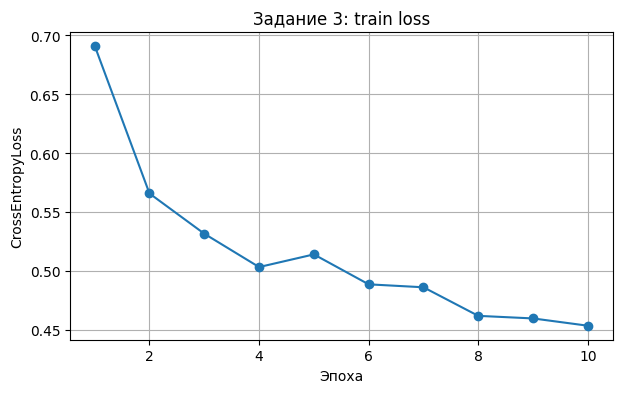

In [48]:
epochs3 = np.arange(1, len(task3_history['train_loss']) + 1)
plt.figure(figsize=(7,4))
plt.plot(epochs3, task3_history['train_loss'], marker='o')
plt.xlabel('Эпоха'); plt.ylabel('CrossEntropyLoss'); plt.title('Задание 3: train loss'); plt.grid(True); plt.show()


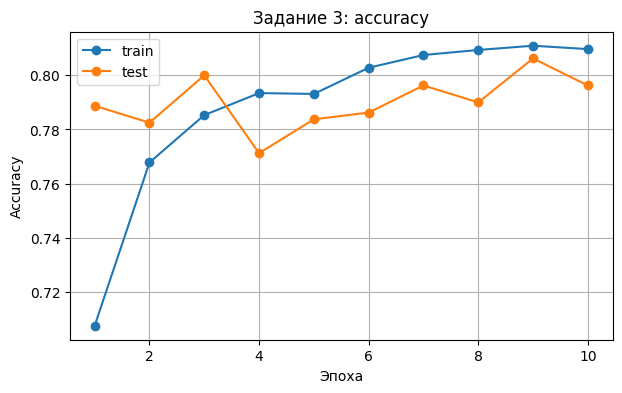

In [49]:
plt.figure(figsize=(7,4))
plt.plot(epochs3, task3_history['train_acc'], marker='o', label='train')
plt.plot(epochs3, task3_history['test_acc'], marker='o', label='test')
plt.xlabel('Эпоха'); plt.ylabel('Accuracy'); plt.title('Задание 3: accuracy'); plt.legend(); plt.grid(True); plt.show()


In [51]:
print('ИТОГ ЗАДАНИЯ 3')
print(f'Train accuracy: {final_train_acc_task3:.2%}')
print(f'Test accuracy:  {final_test_acc_task3:.2%}')
print(f'Trainable parameters: {trainable_task3:,}')


ИТОГ ЗАДАНИЯ 3
Train accuracy: 90.00%
Test accuracy:  79.62%
Trainable parameters: 16,388


<p class="task" id="4"></p>

4\. Повторите решение предыдущей задачи, заморозив все сверточные слои, кроме последнего (слои классификатора не замораживайте). Сравните качество полученного решения и решения из предыдущей задачи, а также время, затраченное на обучения моделей. Перед началом работы создайте модель заново.

- [ ] Проверено на семинаре

In [57]:
def create_model_partially_frozen(num_classes):
    model = models.vgg16(weights=VGG_WEIGHTS)
    for p in model.parameters():
        p.requires_grad = False

    # Последний именно сверточный слой VGG16.
    last_conv = None
    last_conv_name = None
    for name, module in model.features.named_modules():
        if isinstance(module, nn.Conv2d):
            last_conv = module
            last_conv_name = name
    for p in last_conv.parameters():
        p.requires_grad = True

    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(in_features, num_classes)
    for p in model.classifier.parameters():
        p.requires_grad = True

    print('Последний обучаемый Conv2d в features:', last_conv_name, last_conv)
    return model


In [58]:
def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [59]:
model_task4 = create_model_partially_frozen(num_classes).to(device)
trainable_task4 = count_trainable(model_task4)
print(f'Обучаемых параметров задания 4: {trainable_task4:,}')
task4_history = train_classifier(
    model_task4, train_loader, test_loader,
    epochs=10, lr=1e-4, label='VGG16 / последний Conv2d + classifier'
)
torch.save(model_task4.state_dict(), 'vgg16_task4_partial_finetune.pth')


Последний обучаемый Conv2d в features: 28 Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Обучаемых параметров задания 4: 121,922,052
VGG16 / последний Conv2d + classifier | epoch 01/10 | loss=0.6283 | train_acc=0.7403 | test_acc=0.8087
VGG16 / последний Conv2d + classifier | epoch 02/10 | loss=0.2956 | train_acc=0.8819 | test_acc=0.7825
VGG16 / последний Conv2d + classifier | epoch 03/10 | loss=0.1122 | train_acc=0.9547 | test_acc=0.8125
VGG16 / последний Conv2d + classifier | epoch 04/10 | loss=0.0400 | train_acc=0.9866 | test_acc=0.8100
VGG16 / последний Conv2d + classifier | epoch 05/10 | loss=0.0285 | train_acc=0.9888 | test_acc=0.8075
VGG16 / последний Conv2d + classifier | epoch 06/10 | loss=0.0161 | train_acc=0.9947 | test_acc=0.8113
VGG16 / последний Conv2d + classifier | epoch 07/10 | loss=0.0090 | train_acc=0.9972 | test_acc=0.8125
VGG16 / последний Conv2d + classifier | epoch 08/10 | loss=0.0012 | train_acc=1.0000 | test_acc=0.8125
VGG16 / последний Conv

In [61]:
final_train_acc_task4, final_test_acc_task4 = evaluate_model(model_task4, train_loader, test_loader)
print(f'Task 3 test accuracy: {final_test_acc_task3:.4f}')
print(f'Task 4 test accuracy: {final_test_acc_task4:.4f}')
print(f'Task 3 time: {task3_history["total_time"]:.1f} c')
print(f'Task 4 time: {task4_history["total_time"]:.1f} c')


Task 3 test accuracy: 0.7963
Task 4 test accuracy: 0.8163
Task 3 time: 32.7 c
Task 4 time: 33.5 c


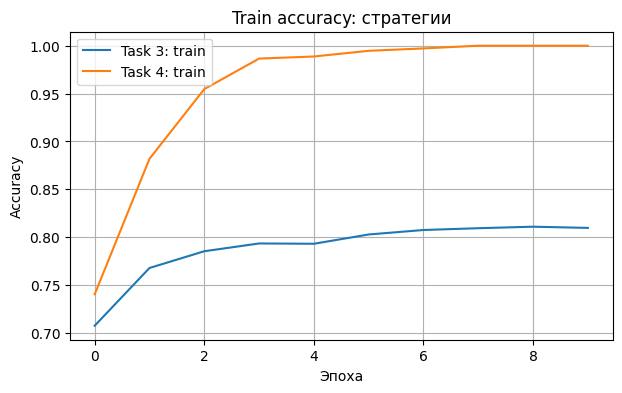

In [62]:
plt.figure(figsize=(7,4))
plt.plot(task3_history['train_acc'], label='Task 3: train')
plt.plot(task4_history['train_acc'], label='Task 4: train')
plt.xlabel('Эпоха'); plt.ylabel('Accuracy'); plt.title('Train accuracy: стратегии'); plt.legend(); plt.grid(True); plt.show()


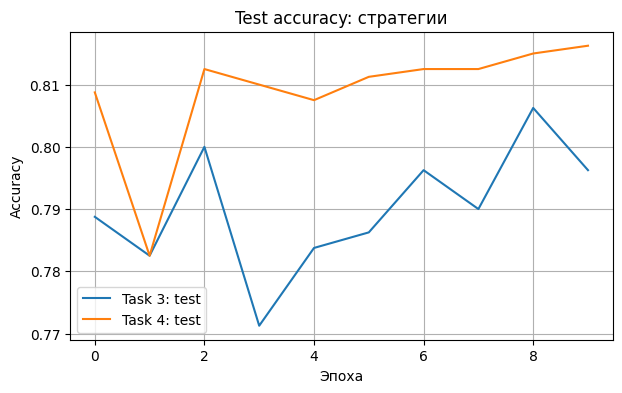

In [63]:
plt.figure(figsize=(7,4))
plt.plot(task3_history['test_acc'], label='Task 3: test')
plt.plot(task4_history['test_acc'], label='Task 4: test')
plt.xlabel('Эпоха'); plt.ylabel('Accuracy'); plt.title('Test accuracy: стратегии'); plt.legend(); plt.grid(True); plt.show()


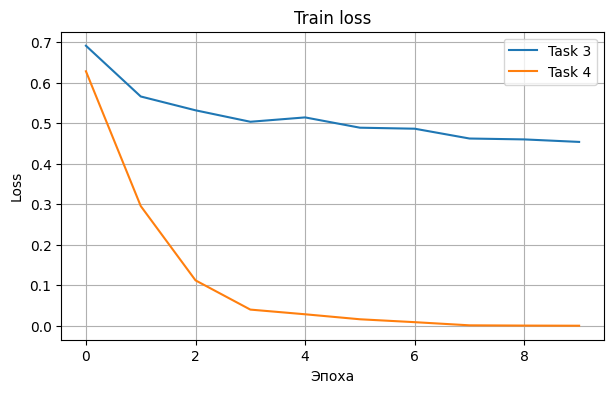

In [64]:
plt.figure(figsize=(7,4))
plt.plot(task3_history['train_loss'], label='Task 3')
plt.plot(task4_history['train_loss'], label='Task 4')
plt.xlabel('Эпоха'); plt.ylabel('Loss'); plt.title('Train loss'); plt.legend(); plt.grid(True); plt.show()


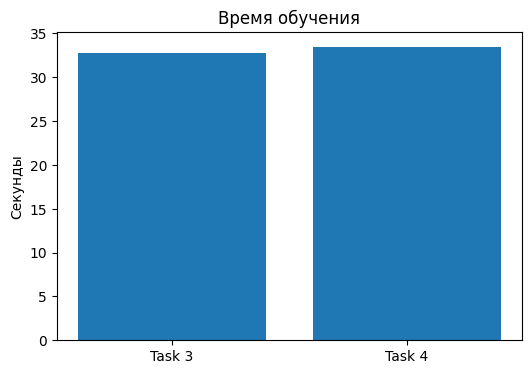

In [65]:
labels_cmp = ['Task 3', 'Task 4']
times_cmp = [task3_history['total_time'], task4_history['total_time']]
plt.figure(figsize=(6,4)); plt.bar(labels_cmp, times_cmp); plt.ylabel('Секунды'); plt.title('Время обучения'); plt.show()


In [66]:
comparison_results = {
    'task3': {'train_acc': final_train_acc_task3, 'test_acc': final_test_acc_task3,
              'time': task3_history['total_time'], 'trainable': trainable_task3},
    'task4': {'train_acc': final_train_acc_task4, 'test_acc': final_test_acc_task4,
              'time': task4_history['total_time'], 'trainable': trainable_task4},
}
print(comparison_results)


{'task3': {'train_acc': 0.9, 'test_acc': 0.79625, 'time': 32.7186162550006, 'trainable': 16388}, 'task4': {'train_acc': 1.0, 'test_acc': 0.81625, 'time': 33.454177597000125, 'trainable': 121922052}}


<p class="task" id="5"></p>

5\. Повторите решение задачи 3, расширив обучающий набор данных при помощи преобразований из `torchvision`, изменяющих изображение (повороты, изменение интенсивности пикселей, обрезание и т.д.). При оценке модели на тестовой выборке данные преобразования применяться не должны. Решение о том, сколько и каких слоев модели будет обучаться, примите самостоятельно. Перед началом работы создайте модель заново.

- [ ] Проверено на семинаре

In [68]:
class AugmentedCatBreedsDataset(CatBreedsDataset):
    pass


In [69]:
def get_advanced_transforms():
    train_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop((224, 224), scale=(0.80, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(12),
        transforms.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.20, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ])
    test_transform = VGG_WEIGHTS.transforms()  # никаких аугментаций на test
    return train_transform, test_transform


In [70]:
def visualize_augmentations(image_path, transform, repeats=6):
    image = Image.open(image_path).convert('RGB')
    fig, axes = plt.subplots(2, 3, figsize=(10, 7))
    for ax in axes.ravel()[:repeats]:
        x = transform(image)
        x = denormalize_imagenet(x).permute(1,2,0).cpu().numpy()
        ax.imshow(x)
        ax.axis('off')
    fig.suptitle('Примеры train-аугментаций (после denormalization)')
    plt.tight_layout(); plt.show()


In [71]:
def create_augmented_datasets(batch_size=32):
    train_tf, test_tf = get_advanced_transforms()
    train_aug = CatBreedsDataset(cat_data['train_paths'], cat_data['train_labels'], class_to_idx, train_tf)
    test_aug = CatBreedsDataset(cat_data['test_paths'], cat_data['test_labels'], class_to_idx, test_tf)
    train_dl, test_dl = create_dataloaders(train_aug, test_aug, batch_size=batch_size)
    return train_aug, test_aug, train_dl, test_dl


In [72]:
print('Устройство задания 5:', device)


Устройство задания 5: cuda


In [73]:
def setup_enhanced_model(num_classes):
    model = models.vgg16(weights=VGG_WEIGHTS)
    for p in model.parameters():
        p.requires_grad = False

    # В VGG16 block5 начинается с Conv2d features[24].
    for p in model.features[24:].parameters():
        p.requires_grad = True

    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(in_features, num_classes)
    for p in model.classifier.parameters():
        p.requires_grad = True

    print(f'Обучаемых параметров task5: {count_trainable(model):,}')
    return model.to(device)

In [74]:
def train_enhanced_model(model, train_loader, test_loader, num_epochs=10, learning_rate=1e-4):
    return train_classifier(model, train_loader, test_loader, epochs=num_epochs,
                            lr=learning_rate, label='VGG16 / augmentation + block5 + classifier')


In [75]:
def plot_enhanced_training_metrics(history):
    e = np.arange(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13,4))
    axes[0].plot(e, history['train_loss'], marker='o')
    axes[0].set_title('Train loss'); axes[0].set_xlabel('Эпоха'); axes[0].grid(True)
    axes[1].plot(e, history['train_acc'], marker='o', label='train')
    axes[1].plot(e, history['test_acc'], marker='o', label='test')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Эпоха'); axes[1].legend(); axes[1].grid(True)
    plt.tight_layout(); plt.show()


In [76]:
def evaluate_final_model(model, train_loader, test_loader):
    tr_acc, te_acc = evaluate_model(model, train_loader, test_loader)
    print(f'Final train accuracy: {tr_acc:.4f}')
    print(f'Final test accuracy:  {te_acc:.4f}')
    print('Аугментации применялись только к train — test всегда оценивается без случайных искажений.')
    return tr_acc, te_acc


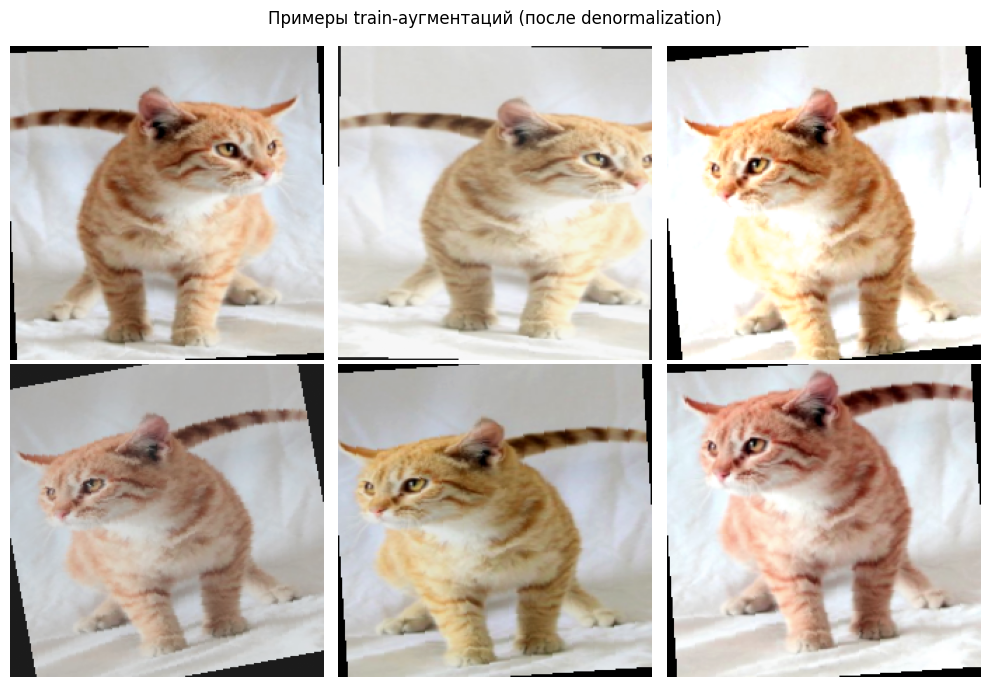

Обучаемых параметров task5: 126,641,668
VGG16 / augmentation + block5 + classifier | epoch 01/10 | loss=0.6770 | train_acc=0.7244 | test_acc=0.7950
VGG16 / augmentation + block5 + classifier | epoch 02/10 | loss=0.4698 | train_acc=0.8166 | test_acc=0.8187
VGG16 / augmentation + block5 + classifier | epoch 03/10 | loss=0.4007 | train_acc=0.8406 | test_acc=0.8087
VGG16 / augmentation + block5 + classifier | epoch 04/10 | loss=0.3358 | train_acc=0.8725 | test_acc=0.8213
VGG16 / augmentation + block5 + classifier | epoch 05/10 | loss=0.2736 | train_acc=0.8912 | test_acc=0.8037
VGG16 / augmentation + block5 + classifier | epoch 06/10 | loss=0.2499 | train_acc=0.9053 | test_acc=0.7963
VGG16 / augmentation + block5 + classifier | epoch 07/10 | loss=0.1951 | train_acc=0.9247 | test_acc=0.7850
VGG16 / augmentation + block5 + classifier | epoch 08/10 | loss=0.1805 | train_acc=0.9291 | test_acc=0.7788
VGG16 / augmentation + block5 + classifier | epoch 09/10 | loss=0.1481 | train_acc=0.9475 | test

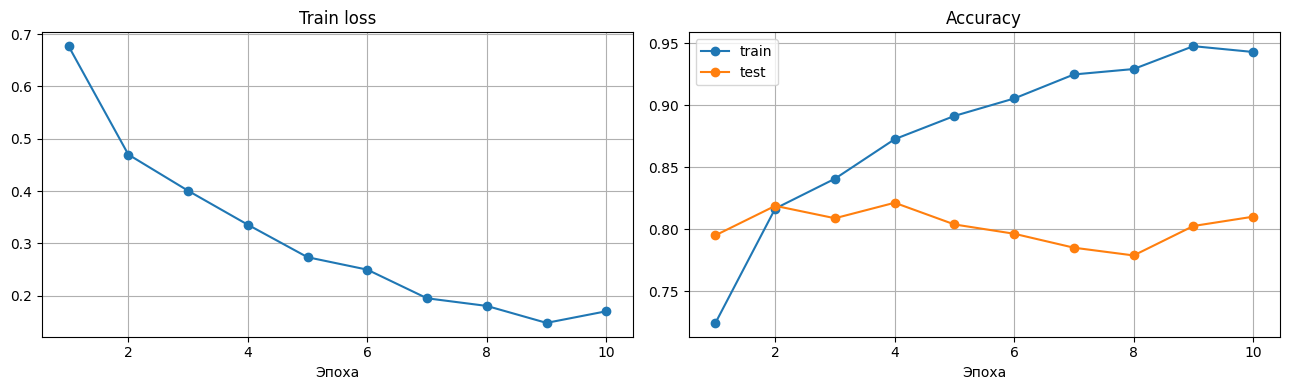

Final train accuracy: 0.9697
Final test accuracy:  0.8100
Аугментации применялись только к train — test всегда оценивается без случайных искажений.

Сравнение test accuracy:
Task 3 (только последний Linear): 0.7963
Task 4 (последний Conv + classifier): 0.8163
Task 5 (augmentation + block5 + classifier): 0.8100


In [77]:
train_aug_dataset, test_aug_dataset, train_aug_loader, test_aug_loader = create_augmented_datasets(batch_size=32)
visualize_augmentations(cat_data['train_paths'][0], get_advanced_transforms()[0])

model_task5 = setup_enhanced_model(num_classes)
task5_history = train_enhanced_model(model_task5, train_aug_loader, test_aug_loader, num_epochs=10, learning_rate=1e-4)
plot_enhanced_training_metrics(task5_history)
final_train_acc_task5, final_test_acc_task5 = evaluate_final_model(model_task5, train_aug_loader, test_aug_loader)
torch.save(model_task5.state_dict(), 'vgg16_task5_augmented.pth')

print('\nСравнение test accuracy:')
print(f'Task 3 (только последний Linear): {final_test_acc_task3:.4f}')
print(f'Task 4 (последний Conv + classifier): {final_test_acc_task4:.4f}')
print(f'Task 5 (augmentation + block5 + classifier): {final_test_acc_task5:.4f}')


## Обратная связь
- [ ] Почта: d83073452@yandex.ru
- [ ] Gmail: 3073452@gmail.com
- [ ] Telegram: @sleepingzzzZ